# Análisis de Películas de Studio Ghibli con SQL y Pandas

Este notebook explora la base de datos `ghibli.db` y realiza diversas consultas SQL para analizar películas del estudio.

## Contenido
- Consultas simples y filtradas
- Consultas agrupadas
- Consultas avanzadas
- Visualizaciones con Pandas y Matplotlib

---

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Conectar a la base de datos
conn = sqlite3.connect('ghibli.db')


In [3]:
from sqlalchemy import create_engine
from sqlalchemy.exc import SQLAlchemyError
import sqlite3

db_path = 'ghibli.db'

# Intentar conexión con sqlite3
try:
    conn = sqlite3.connect(db_path)
    print("Conexión exitosa con sqlite3")
except sqlite3.Error as e:
    print(f"Fallo de conexión con sqlite3: {e}")
    conn = None

# Intentar conexión con SQLAlchemy
try:
    engine = create_engine(f"sqlite:///{db_path}")
    sqlalchemy_conn = engine.connect()
    print("Conexión exitosa con SQLAlchemy")
except SQLAlchemyError as e:
    print(f"Fallo de conexión con SQLAlchemy: {e}")
    sqlalchemy_conn = None

ModuleNotFoundError: No module named 'sqlalchemy'

## 1. Consultas básicas

In [ ]:
# 1. Películas ordenadas por año
consulta = """
SELECT title, release_date FROM df ORDER BY release_date
"""
pd.read_sql(consulta, conn)

,title,release_date
0,Castle in the Sky,1986-01-01 00:00:00.000000
1,Grave of the Fireflies,1988-01-01 00:00:00.000000
2,My Neighbor Totoro,1988-01-01 00:00:00.000000
3,Kiki's Delivery Service,1989-01-01 00:00:00.000000
4,Only Yesterday,1991-01-01 00:00:00.000000
5,Porco Rosso,1992-01-01 00:00:00.000000
6,Pom Poko,1994-01-01 00:00:00.000000
7,Whisper of the Heart,1995-01-01 00:00:00.000000
8,Princess Mononoke,1997-01-01 00:00:00.000000
9,My Neighbors the Yamadas,1999-01-01 00:00:00.000000


In [3]:
# 2. Películas dirigidas por Hayao Miyazaki
pd.read_sql("""
SELECT title, director FROM df WHERE director = 'Hayao Miyazaki'
""", conn)

,title,director
0,Castle in the Sky,Hayao Miyazaki
1,My Neighbor Totoro,Hayao Miyazaki
2,Kiki's Delivery Service,Hayao Miyazaki
3,Porco Rosso,Hayao Miyazaki
4,Princess Mononoke,Hayao Miyazaki
5,Spirited Away,Hayao Miyazaki
6,Howl's Moving Castle,Hayao Miyazaki
7,Ponyo,Hayao Miyazaki
8,The Wind Rises,Hayao Miyazaki


In [4]:
# 3. Películas con duración mayor a 100 minutos
pd.read_sql("""
SELECT title, running_time FROM df WHERE running_time > 100
""", conn)

,title,running_time
0,Castle in the Sky,124
1,Kiki's Delivery Service,102
2,Only Yesterday,118
3,Pom Poko,119
4,Whisper of the Heart,111
5,Princess Mononoke,134
6,My Neighbors the Yamadas,104
7,Spirited Away,124
8,Howl's Moving Castle,119
9,Tales from Earthsea,116


In [5]:
# 4. Películas con calificación mayor a 90
pd.read_sql("""
SELECT title, rt_score FROM df WHERE rt_score > 90
""", conn)

,title,rt_score
0,Castle in the Sky,95
1,Grave of the Fireflies,97
2,My Neighbor Totoro,93
3,Kiki's Delivery Service,96
4,Only Yesterday,100
5,Porco Rosso,94
6,Whisper of the Heart,91
7,Princess Mononoke,92
8,Spirited Away,97
9,Ponyo,92


## 2. Consultas agrupadas

In [6]:
# 5. Promedio de duración por década
pd.read_sql("""
SELECT decada, AVG(running_time) AS promedio_duracion
FROM df GROUP BY decada
""", conn)

,decada,promedio_duracion
0,1980,100.250000
1,1990,113.166667
2,2000,106.800000
3,2010,105.166667
4,2020,82.000000


In [7]:
# 6. Promedio de rt_score por director
pd.read_sql("""
SELECT director, AVG(rt_score) AS promedio_puntuacion
FROM df GROUP BY director
""", conn)

,director,promedio_puntuacion
0,Gorō Miyazaki,51.333333
1,Hayao Miyazaki,92.777778
2,Hiromasa Yonebayashi,93.500000
3,Hiroyuki Morita,89.000000
4,Isao Takahata,90.000000
5,Michaël Dudok de Wit,93.000000
6,Yoshifumi Kondō,91.000000


In [8]:
# 7. Número de películas por productor
pd.read_sql("""
SELECT producer, COUNT(*) AS num_peliculas FROM df GROUP BY producer
""", conn)

,producer,num_peliculas
0,Hayao Miyazaki,2
1,Isao Takahata,1
2,Toru Hara,1
3,Toshio Suzuki,15
4,"Toshio Suzuki, Isao Takahata, Vincent Maraval,...",1
5,Yoshiaki Nishimura,2


In [9]:
# 8. Película más larga y más corta
pd.read_sql("""
SELECT title, running_time FROM df
WHERE running_time = (SELECT MAX(running_time) FROM df)
   OR running_time = (SELECT MIN(running_time) FROM df)
""", conn)

,title,running_time
0,The Cat Returns,75
1,The Tale of the Princess Kaguya,137


## 3. Consultas avanzadas

In [10]:
# 9. Década con mayor duración promedio
pd.read_sql("""
SELECT decada, AVG(running_time) AS duracion_media
FROM df GROUP BY decada ORDER BY duracion_media DESC LIMIT 1
""", conn)

,decada,duracion_media
0,1990,113.166667


In [11]:
# 10. Trimestre con mejor puntuación promedio
pd.read_sql("""
SELECT trimestre, AVG(rt_score) AS promedio FROM df
GROUP BY trimestre ORDER BY promedio DESC
""", conn)

,trimestre,promedio
0,1,86.318182


## 4. Visualizaciones con Pandas

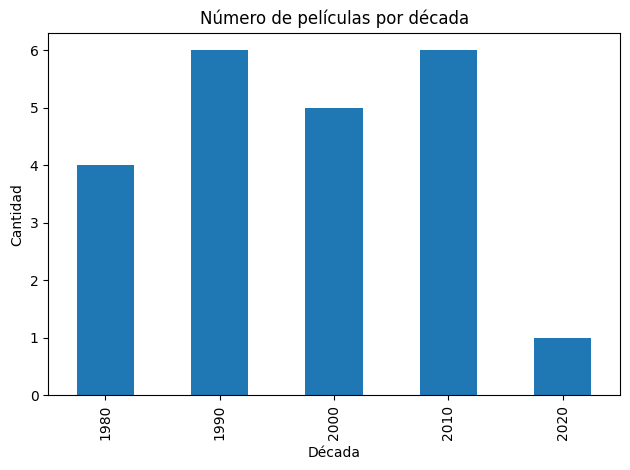

In [12]:
# Número de películas por década
df = pd.read_sql("SELECT * FROM df", conn)
df['decada'].value_counts().sort_index().plot(kind='bar', title='Número de películas por década')
plt.ylabel('Cantidad')
plt.xlabel('Década')
plt.tight_layout()
plt.show()

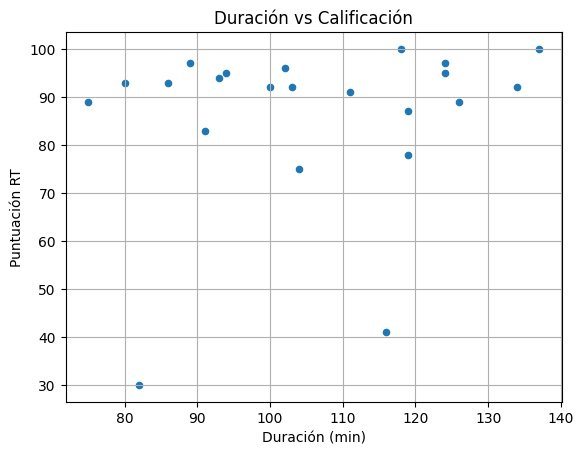

In [13]:
# Dispersión: duración vs puntuación
df.plot.scatter(x='running_time', y='rt_score', title='Duración vs Calificación')
plt.xlabel('Duración (min)')
plt.ylabel('Puntuación RT')
plt.grid(True)
plt.show()

In [16]:
df.query("director == 'Hayao Miyazaki' and running_time > 100") 

,Unnamed: 0,id,title,original_title,original_title_romanised,image,movie_banner,description,director,producer,...,rt_score,people,species,locations,vehicles,url,description_length,decada,trimestre,clasificacion_duracion
0,0,2baf70d1-42bb-4437-b551-e5fed5a87abe,Castle in the Sky,天空の城ラピュタ,Tenkū no shiro Rapyuta,https://image.tmdb.org/t/p/w600_and_h900_bestv...,https://image.tmdb.org/t/p/w533_and_h300_bestv...,The orphan Sheeta inherited a mysterious cryst...,Hayao Miyazaki,Isao Takahata,...,95,['https://ghibli-api.vercel.app/api/people/598...,['https://ghibli-api.vercel.app/api/species/af...,['https://ghibli-api.vercel.app/api/locations/'],['https://ghibli-api.vercel.app/api/vehicles/4...,https://ghibli-api.vercel.app/api/films/2baf70...,351,1980,1,larga
3,3,ea660b10-85c4-4ae3-8a5f-41cea3648e3e,Kiki's Delivery Service,魔女の宅急便,Majo no takkyūbin,https://image.tmdb.org/t/p/w600_and_h900_bestv...,https://image.tmdb.org/t/p/original/h5pAEVma83...,"A young witch, on her mandatory year of indepe...",Hayao Miyazaki,Hayao Miyazaki,...,96,['https://ghibli-api.vercel.app/api/people/240...,['https://ghibli-api.vercel.app/api/species/af...,['https://ghibli-api.vercel.app/api/locations/'],['https://ghibli-api.vercel.app/api/vehicles/'],https://ghibli-api.vercel.app/api/films/ea660b...,164,1980,1,larga
8,8,0440483e-ca0e-4120-8c50-4c8cd9b965d6,Princess Mononoke,もののけ姫,Mononoke hime,https://image.tmdb.org/t/p/w600_and_h900_bestv...,https://image.tmdb.org/t/p/original/6pTqSq0zYI...,"Ashitaka, a prince of the disappearing Ainu tr...",Hayao Miyazaki,Toshio Suzuki,...,92,['https://ghibli-api.vercel.app/api/people/ba9...,['https://ghibli-api.vercel.app/api/species/af...,['https://ghibli-api.vercel.app/api/locations/'],['https://ghibli-api.vercel.app/api/vehicles/'],https://ghibli-api.vercel.app/api/films/044048...,321,1990,1,larga
10,10,dc2e6bd1-8156-4886-adff-b39e6043af0c,Spirited Away,千と千尋の神隠し,Sen to Chihiro no kamikakushi,https://image.tmdb.org/t/p/w600_and_h900_bestv...,https://image.tmdb.org/t/p/original/bSXfU4dwZy...,Spirited Away is an Oscar winning Japanese ani...,Hayao Miyazaki,Toshio Suzuki,...,97,['https://ghibli-api.vercel.app/api/people/822...,['https://ghibli-api.vercel.app/api/species/af...,['https://ghibli-api.vercel.app/api/locations/'],['https://ghibli-api.vercel.app/api/vehicles/'],https://ghibli-api.vercel.app/api/films/dc2e6b...,349,2000,1,larga
12,12,cd3d059c-09f4-4ff3-8d63-bc765a5184fa,Howl's Moving Castle,ハウルの動く城,Hauru no ugoku shiro,https://image.tmdb.org/t/p/w600_and_h900_bestv...,https://image.tmdb.org/t/p/original/hjlvbMKhQm...,"When Sophie, a shy young woman, is cursed with...",Hayao Miyazaki,Toshio Suzuki,...,87,['https://ghibli-api.vercel.app/api/people/'],['https://ghibli-api.vercel.app/api/species/af...,['https://ghibli-api.vercel.app/api/locations/'],['https://ghibli-api.vercel.app/api/vehicles/'],https://ghibli-api.vercel.app/api/films/cd3d05...,218,2000,1,larga
17,17,67405111-37a5-438f-81cc-4666af60c800,The Wind Rises,風立ちぬ,Kaze tachinu,https://image.tmdb.org/t/p/w600_and_h900_bestv...,https://image.tmdb.org/t/p/original/stM3jlD4nS...,A lifelong love of flight inspires Japanese av...,Hayao Miyazaki,Toshio Suzuki,...,89,['https://ghibli-api.vercel.app/api/people/'],['https://ghibli-api.vercel.app/api/species/af...,['https://ghibli-api.vercel.app/api/locations/'],['https://ghibli-api.vercel.app/api/vehicles/'],https://ghibli-api.vercel.app/api/films/674051...,160,2010,1,larga
